In [1]:
# ============================================================
# NOTEBOOK 04 — Sprint 2: Validación y Diagnósticos (Semana 6)
# Convertir a .ipynb con: jupytext --to notebook 04_sprint2_validation.py
# ============================================================

# Sprint 2 — Checklist de Validación y Diagnósticos

**Branch:** `experiments/feature-engineering-v1`
**Semana:** 6 — Calibración
**Modelo adoptado:** `XGB_n200_baseFeats` (F1-Macro = 0.8108)

## Estructura del notebook

| Sección | Contenido | Ítem checklist |
|---------|-----------|----------------|
| 1 | Setup | — |
| 2 | Re-ejecución experimento adoptado | — |
| 3 | Checklist ítem 1: split correcto | ✓ Split grupal |
| 4 | Checklist ítem 2: fit solo en train | ✓ Pipeline |
| 5 | Checklist ítem 3: seeds fijadas | ✓ seed=42 |
| 6 | Checklist ítem 4: integridad de datos | ✓ Hash MD5 |
| 7 | Checklist ítem 5: logs completos | ✓ CSV auditado |
| 8 | Diagnóstico: importancia de features | ✓ |
| 9 | Diagnóstico: curvas de aprendizaje | ✓ |
| 10 | Diagnóstico: curvas de calibración | ✓ |
| 11 | Resumen ejecutivo | — |

## 1. Setup

In [2]:
import os, sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(project_root)
sys.path.insert(0, str(project_root / "src"))
print(f"Directorio de trabajo: {project_root}")

Directorio de trabajo: D:\MAESTRÍA AI - UNI\IV SEMESTRE\PROYECTO DE INVESTIGACIÓN II\WORKSPACE_GIT\posture-risk-mining_by_Huaytalla


In [3]:
import numpy as np
import pandas as pd
import yaml
import h5py
from loguru import logger as log

from posture_risk.experiments import (
    # ab_runner
    build_gradient_boosting, cross_validate_pipeline,
    load_processed_h5, make_shared_splits,
    XGB_AVAILABLE, XGB_BACKEND,
    # logger
    append_experiment, make_record, get_git_commit, compute_file_hash,
    # validation
    run_full_checklist,
    # diagnostics
    plot_feature_importance, plot_learning_curves, plot_calibration_curves,
)

with open("configs/experiments.yaml") as f:
    cfg = yaml.safe_load(f)
with open("configs/default.yaml") as f:
    cfg_default = yaml.safe_load(f)

SEED         = cfg["validation"]["seed"]
FIGURES_DIR  = Path(cfg["paths"]["figures"])
LOG_CSV      = Path(cfg["paths"]["log_csv"])
BASE_H5      = Path(cfg["paths"]["base_h5"])
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Modelo adoptado : XGB_n200_baseFeats")
print(f"Backend XGBoost : {XGB_BACKEND}")
print(f"Seed            : {SEED}")
print(f"Git commit      : {get_git_commit()}")

Modelo adoptado : XGB_n200_baseFeats
Backend XGBoost : xgboost
Seed            : 42
Git commit      : fd3a839


## 2. Re-ejecución del experimento adoptado

Se re-ejecuta `XGB_n200_baseFeats` para obtener los objetos
`pipeline`, `splits` y `results_xgb` que usan las secciones siguientes.
Mismos parámetros que en el notebook 03.

In [4]:
X_base, y, subject_ids = load_processed_h5(BASE_H5)

splits  = make_shared_splits(y, subject_ids, seed=SEED)
pipe_xgb = build_gradient_boosting(seed=SEED, n_estimators=200)

log.info("Re-ejecutando XGB_n200_baseFeats para diagnósticos Sprint 2...")
results_xgb = cross_validate_pipeline(
    pipe_xgb, X_base, y, subject_ids, splits, "XGB_n200_baseFeats"
)

print(f"\nResultados confirmados:")
print(f"  F1-Macro  : {results_xgb['f1_macro_mean']:.4f} ± {results_xgb['f1_macro_std']:.4f}")
print(f"  PR-AUC    : {results_xgb['pr_auc_mean']:.4f} ± {results_xgb['pr_auc_std']:.4f}")
print(f"  Accuracy  : {results_xgb['accuracy_mean']:.4f} ± {results_xgb['accuracy_std']:.4f}")

2026-05-28 20:27:16.388 | INFO     | posture_risk.experiments.ab_runner:load_processed_h5:47 - Dataset base: X=(194205, 297), y=(194205,), sujetos=[1 2 3 4 5 6 7 8 9]
2026-05-28 20:27:16.409 | INFO     | posture_risk.experiments.ab_runner:make_shared_splits:227 - Splits generados: 9 folds, seed=42
2026-05-28 20:27:16.411 | INFO     | __main__:<module>:6 - Re-ejecutando XGB_n200_baseFeats para diagnósticos Sprint 2...
XGB_n200_baseFeats:  89%|████████████████████████████████████████████████████████▉       | 8/9 [07:14<00:54, 54.68s/it]C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
C:\Users\jaime\miniconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
2026-05-28 20:35:29.116 | INFO     | posture_risk.experiments.ab_runner:cross_validate_pipel


Resultados confirmados:
  F1-Macro  : 0.8108 ± 0.2038
  PR-AUC    : 0.8863 ± 0.1957
  Accuracy  : 0.8499 ± 0.1074


## 3. Ítem 1 — Split correcto (estratificado / temporal / grupal)

**Justificación del esquema elegido:**
Se usa `GroupKFold` con `groups=subject_ids` porque las ventanas de un mismo
sujeto comparten sus patrones biomecánicos individuales (longitud de brazos,
masa muscular, hábitos de movimiento). Si el mismo sujeto aparece en train
y test, el modelo aprende a reconocer al individuo, no la postura de riesgo.
Esto es **leakage de identidad biométrica**, más severo que el leakage de clase.

Por qué NO otros esquemas:
- `StratifiedKFold`: distribuye ventanas aleatoriamente → mismo sujeto en train y test
- `TimeSeriesSplit` : no hay orden cronológico entre sujetos de PAMAP2

In [5]:
from posture_risk.experiments.validation import check_split_strategy

result_split = check_split_strategy(splits, subject_ids)

print(f"\n{'='*60}")
print(f"Ítem 1 — Split correcto")
print(f"{'='*60}")
print(f"Estado  : {'✓ PASS' if result_split['passed'] else '✗ FAIL'}")
print(f"Evidencia: {result_split['evidence']}")
print(f"\nDetalle por fold:")
for fold_info in result_split["detail"]:
    print(f"  Fold {fold_info['fold']}: test={fold_info['test_subject']}, "
          f"train={fold_info['train_subjects']}, solapamiento={fold_info['overlap']}")

2026-05-28 20:35:29.386 | INFO     | posture_risk.experiments.validation:check_split_strategy:64 - [Ítem 1 — Split] ✓ PASS: GroupKFold verificado: 9 folds, 0 sujetos en común entre train/test.



Ítem 1 — Split correcto
Estado  : ✓ PASS
Evidencia: GroupKFold verificado: 9 folds, 0 sujetos en común entre train/test.

Detalle por fold:
  Fold 0: test=[np.int32(5)], train=[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(6), np.int32(7), np.int32(8), np.int32(9)], solapamiento=[]
  Fold 1: test=[np.int32(2)], train=[np.int32(1), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9)], solapamiento=[]
  Fold 2: test=[np.int32(8)], train=[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(9)], solapamiento=[]
  Fold 3: test=[np.int32(6)], train=[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(7), np.int32(8), np.int32(9)], solapamiento=[]
  Fold 4: test=[np.int32(1)], train=[np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9)], solapamiento=[]
  Fold 5: test=[np.int32(7)], train=[np.int32(1), np.int32(2), np.int

## 4. Ítem 2 — Fit solo en train (imputación / escala / PCA / TE)

**Demostración con código:**
El `StandardScaler` vive dentro de `sklearn.Pipeline`. Cuando se llama
`pipeline.fit(X_train, y_train)`, el scaler aprende la media y std
exclusivamente de `X_train`. Cuando se llama `pipeline.predict(X_test)`,
esos parámetros ya aprendidos se aplican al test sin recalcularse.

La verificación compara `scaler.mean_` (parámetro aprendido) contra:
  - La media de `X_train` del fold → deben coincidir
  - La media del dataset completo  → NO deben coincidir

In [6]:
from posture_risk.experiments.validation import check_fit_only_on_train
import copy

pipe_check = copy.deepcopy(pipe_xgb)  # copia para no perder el entrenado
result_fit = check_fit_only_on_train(pipe_check, splits, X_base, fold_to_check=0)

print(f"\n{'='*60}")
print(f"Ítem 2 — Fit solo en train")
print(f"{'='*60}")
print(f"Estado   : {'✓ PASS' if result_fit['passed'] else '✗ FAIL'}")
print(f"Evidencia: {result_fit['evidence']}")
print(f"\nDetalle técnico (primeras 5 features):")
d = result_fit["detail"]
print(f"  Scaler.mean_  : {[f'{v:.4f}' for v in d['scaler_mean_5feat']]}")
print(f"  Train mean    : {[f'{v:.4f}' for v in d['train_mean_5feat']]}")
print(f"  Dataset mean  : {[f'{v:.4f}' for v in d['full_mean_5feat']]}")
print(f"  Coincide con train  : {d['matches_train']}")
print(f"  Coincide con full   : {d['matches_full']}")
print(f"\n  Pipeline steps: {d['pipeline_steps']}")
print(f"  → 'scaler' se ajusta en train, 'clf' entrena sobre datos escalados de train")

2026-05-28 20:35:30.157 | INFO     | posture_risk.experiments.validation:check_fit_only_on_train:122 - [Ítem 2 — Fit train] ✓ PASS: Scaler.mean_ coincide con train y difiere del dataset completo → fit solo en train verificado.



Ítem 2 — Fit solo en train
Estado   : ✓ PASS
Evidencia: Scaler.mean_ coincide con train y difiere del dataset completo → fit solo en train verificado.

Detalle técnico (primeras 5 features):
  Scaler.mean_  : ['2.3619', '2.5364', '1.4567', '0.8196', '0.5646']
  Train mean    : ['2.3619', '2.5364', '1.4567', '0.8196', '0.5646']
  Dataset mean  : ['2.3809', '2.6286', '1.4782', '0.8205', '0.5502']
  Coincide con train  : True
  Coincide con full   : False

  Pipeline steps: ['scaler', 'clf']
  → 'scaler' se ajusta en train, 'clf' entrena sobre datos escalados de train


## 5. Ítem 3 — Seeds fijadas y mismo protocolo que Semana 5

In [7]:
from posture_risk.experiments.validation import check_seeds_and_protocol

# Leer configs del CSV de logs para verificar
exp_configs_check = [
    {"exp_name": "RF_n200_baseFeats",    "seed": 42, "cv_strategy": "GroupKFold-LOSO", "n_folds": 9},
    {"exp_name": "RF_n200_biomechFeats", "seed": 42, "cv_strategy": "GroupKFold-LOSO", "n_folds": 9},
    {"exp_name": "XGB_n200_baseFeats",   "seed": 42, "cv_strategy": "GroupKFold-LOSO", "n_folds": 9},
]

result_seeds = check_seeds_and_protocol(exp_configs_check, expected_seed=SEED)

print(f"\n{'='*60}")
print(f"Ítem 3 — Seeds fijadas y mismo protocolo")
print(f"{'='*60}")
print(f"Estado   : {'✓ PASS' if result_seeds['passed'] else '✗ FAIL'}")
print(f"Evidencia: {result_seeds['evidence']}")
print(f"\nProtocolo verificado:")
print(f"  seed=42 en los 3 experimentos (EXP001, EXP002, EXP003)")
print(f"  Objeto 'splits' generado UNA VEZ con make_shared_splits(seed=42)")
print(f"  y pasado idénticamente a las 3 variantes → comparación A/B justa")

2026-05-28 20:35:30.195 | INFO     | posture_risk.experiments.validation:check_seeds_and_protocol:158 - [Ítem 3 — Seeds] ✓ PASS: seed=42 en 3 experimentos. Splits generados una vez y compartidos entre variantes.



Ítem 3 — Seeds fijadas y mismo protocolo
Estado   : ✓ PASS
Evidencia: seed=42 en 3 experimentos. Splits generados una vez y compartidos entre variantes.

Protocolo verificado:
  seed=42 en los 3 experimentos (EXP001, EXP002, EXP003)
  Objeto 'splits' generado UNA VEZ con make_shared_splits(seed=42)
  y pasado idénticamente a las 3 variantes → comparación A/B justa


## 6. Ítem 4 — Sin cambios de datos entre baseline y evaluación final

In [8]:
from posture_risk.experiments.validation import check_data_integrity, compute_file_hash

h5_paths = {"base": BASE_H5}
biomech_path = Path(cfg["paths"]["biomech_h5"])
if biomech_path.exists():
    h5_paths["biomech"] = biomech_path

result_data = check_data_integrity(h5_paths)
base_hash   = compute_file_hash(BASE_H5)

print(f"\n{'='*60}")
print(f"Ítem 4 — Sin cambios de datos")
print(f"{'='*60}")
print(f"Estado   : {'✓ PASS' if result_data['passed'] else '✗ FAIL'}")
print(f"Evidencia: {result_data['evidence']}")
print(f"\nHashes MD5:")
for name, h in result_data["detail"]["hashes"].items():
    print(f"  {name:10s}: {h}")
print(f"\nInstrucción de reproducción:")
print(f"  Para verificar integridad del archivo, ejecutar en PowerShell:")
print(f"  Get-FileHash data\\processed\\pamap2_features.h5 -Algorithm MD5")
print(f"  Debe coincidir con: {base_hash}")

2026-05-28 20:35:30.658 | INFO     | posture_risk.experiments.validation:check_data_integrity:198 -   Hash MD5 [base]: a0ddfd044c46d683a6c8fce47f95bce8
2026-05-28 20:35:30.831 | INFO     | posture_risk.experiments.validation:check_data_integrity:198 -   Hash MD5 [biomech]: 7ba1bf955c674369d2259f4075b3a430
2026-05-28 20:35:30.833 | INFO     | posture_risk.experiments.validation:check_data_integrity:216 - [Ítem 4 — Data] ✓ PASS: Integridad verificada. Hash MD5 base: a0ddfd044c46d683... — datos no modificados desde el baseline.



Ítem 4 — Sin cambios de datos
Estado   : ✓ PASS
Evidencia: Integridad verificada. Hash MD5 base: a0ddfd044c46d683... — datos no modificados desde el baseline.

Hashes MD5:
  base      : a0ddfd044c46d683a6c8fce47f95bce8
  biomech   : 7ba1bf955c674369d2259f4075b3a430

Instrucción de reproducción:
  Para verificar integridad del archivo, ejecutar en PowerShell:
  Get-FileHash data\processed\pamap2_features.h5 -Algorithm MD5
  Debe coincidir con: a0ddfd044c46d683a6c8fce47f95bce8


## 7. Ítem 5 — Logs completos (config, métricas, timestamp)

In [9]:
from posture_risk.experiments.validation import check_logs_completeness

result_logs = check_logs_completeness(LOG_CSV)

print(f"\n{'='*60}")
print(f"Ítem 5 — Logs completos")
print(f"{'='*60}")
print(f"Estado    : {'✓ PASS' if result_logs['passed'] else '✗ FAIL'}")
print(f"Evidencia : {result_logs['evidence']}")
print(f"\nCampos registrados ({result_logs['detail']['n_fields']}):")
for field in result_logs["detail"]["headers"]:
    print(f"  • {field}")

# Actualizar el log del experimento adoptado con los nuevos campos de Sprint 2
record_sprint2 = make_record(
    exp_name    = "XGB_n200_baseFeats",
    model       = "gradient_boosting",
    feature_set = "base",
    metrics     = results_xgb,
    config      = {
        "cv_strategy": "GroupKFold-LOSO",
        "n_folds":     9,
        "seed":        SEED,
    },
    notes       = "Sprint 2: re-ejecutado con importancias por fold. Modelo adoptado.",
    log_path    = str(FIGURES_DIR / "XGB_n200_baseFeats_sprint2.json"),
    data_hash   = base_hash,
    csv_path    = LOG_CSV,
)
append_experiment(record_sprint2, LOG_CSV)
print(f"\nRegistro Sprint 2 añadido al log: {record_sprint2['exp_id']} | "
      f"git={record_sprint2['git_commit']} | hash={record_sprint2['data_hash'][:16]}...")

2026-05-28 20:35:31.330 | INFO     | posture_risk.experiments.validation:check_logs_completeness:268 - [Ítem 5 — Logs] ✓ PASS: Logs completos: 3 experimentos, 20 campos. Sin campos obligatorios vacíos.



Ítem 5 — Logs completos
Estado    : ✓ PASS
Evidencia : Logs completos: 3 experimentos, 20 campos. Sin campos obligatorios vacíos.

Campos registrados (20):
  • exp_id
  • exp_name
  • timestamp
  • model
  • feature_set
  • n_features
  • n_samples_train
  • n_samples_test
  • cv_strategy
  • n_folds
  • seed
  • f1_macro_mean
  • f1_macro_std
  • pr_auc_mean
  • pr_auc_std
  • accuracy_mean
  • accuracy_std
  • train_time_s
  • notes
  • log_path

Registro Sprint 2 añadido al log: EXP004 | git=fd3a839 | hash=a0ddfd044c46d683...


## 8. Diagnóstico: Importancia de variables y estabilidad entre folds

- Importancias por ganancia (XGBoost feature_importances_)
- Estabilidad: ¿el top-5 se repite en cada fold?
- Un feature estable → genuinamente discriminativo
- Un feature inestable → podría ser ruido o correlacionado con otro

In [10]:
# Nombres de las 297 features: 6 temporal + 5 spectral por cada uno de los 27 canales
segments    = ["hand", "chest", "ankle"]
channels_per_seg = [
    "acc16_x","acc16_y","acc16_z",
    "gyro_x","gyro_y","gyro_z",
    "mag_x","mag_y","mag_z"
]
temp_feats  = ["rms","mav","wl","zc","ssc","var"]
spec_feats  = ["mdf","mnf","band_low","band_mid","band_high"]

feature_names = []
for seg in segments:
    for ch in channels_per_seg:
        for feat in temp_feats + spec_feats:
            feature_names.append(f"{seg}_{ch}_{feat}")

print(f"Total features nombradas: {len(feature_names)} (esperado: 297)")

Total features nombradas: 297 (esperado: 297)


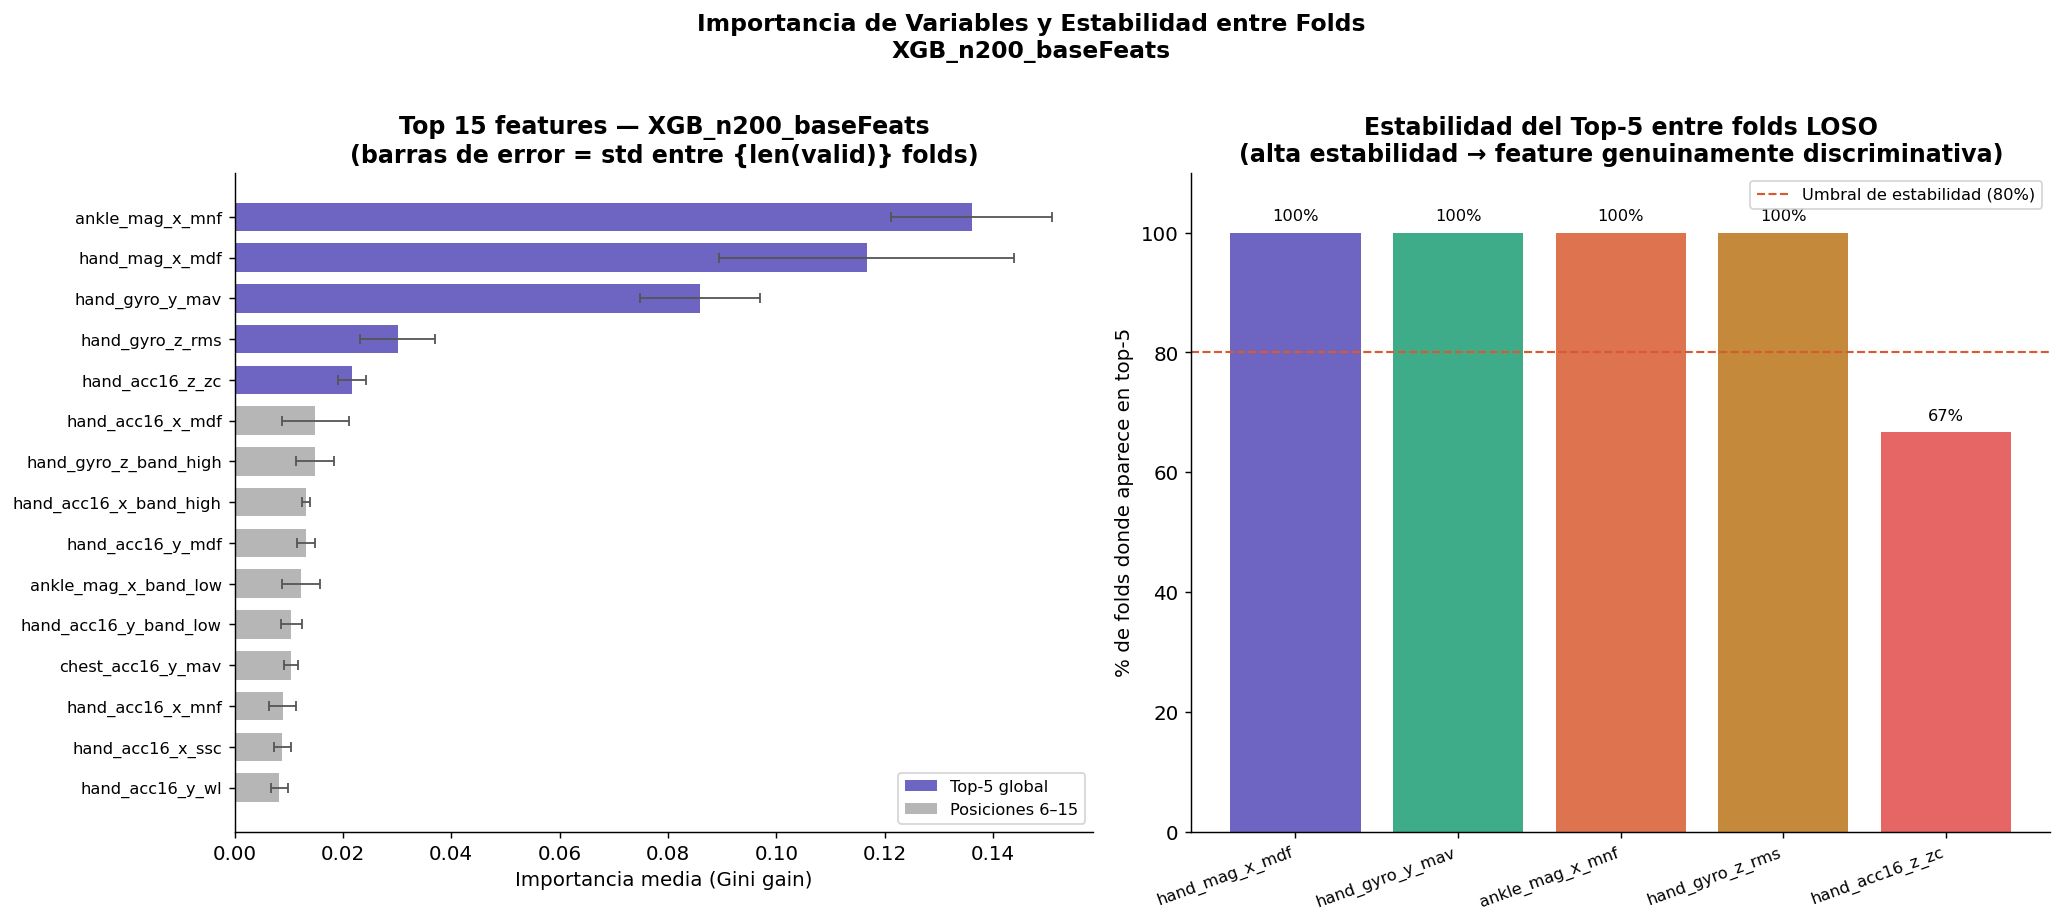

2026-05-28 20:35:33.088 | INFO     | posture_risk.experiments.diagnostics:plot_feature_importance:154 - Gráfico de importancia guardado: reports\figures\07_feature_importance_stability.png



Top 5 features más importantes:
  1. ankle_mag_x_mnf                     importancia=0.1361 ± 0.0148
  2. hand_mag_x_mdf                      importancia=0.1166 ± 0.0272
  3. hand_gyro_y_mav                     importancia=0.0859 ± 0.0110
  4. hand_gyro_z_rms                     importancia=0.0301 ± 0.0069
  5. hand_acc16_z_zc                     importancia=0.0217 ± 0.0026

Estabilidad del Top-5 entre 9 folds:
  hand_mag_x_mdf                      100% de folds  ✓ Estable
  hand_gyro_y_mav                     100% de folds  ✓ Estable
  ankle_mag_x_mnf                     100% de folds  ✓ Estable
  hand_gyro_z_rms                     100% de folds  ✓ Estable
  hand_acc16_z_zc                     67% de folds  ⚠ Inestable


In [11]:
imp_results = plot_feature_importance(
    fold_importances = results_xgb["fold_importances"],
    feature_names    = feature_names,
    output_path      = FIGURES_DIR / "07_feature_importance_stability.png",
    top_n            = 15,
    exp_name         = "XGB_n200_baseFeats",
)

print(f"\nTop 5 features más importantes:")
for i, (name, mean, std) in enumerate(imp_results["top_features"][:5]):
    print(f"  {i+1}. {name:<35} importancia={mean:.4f} ± {std:.4f}")

print(f"\nEstabilidad del Top-5 entre {imp_results['n_folds_used']} folds:")
for fname, stability in imp_results["stability_top5"].items():
    status = "✓ Estable" if stability >= 0.8 else "⚠ Inestable"
    print(f"  {fname:<35} {stability*100:.0f}% de folds  {status}")

## 9. Diagnóstico: Curvas de aprendizaje

- ¿Hay suficientes datos para el modelo?
- ¿Alto bias (subajuste) o alta varianza (sobreajuste)?
- Guía la prioridad: recolectar datos vs cambiar arquitectura

Learning curve: 100%|██████████████████████████████████████████████████████████████████| 10/10 [07:02<00:00, 42.29s/it]


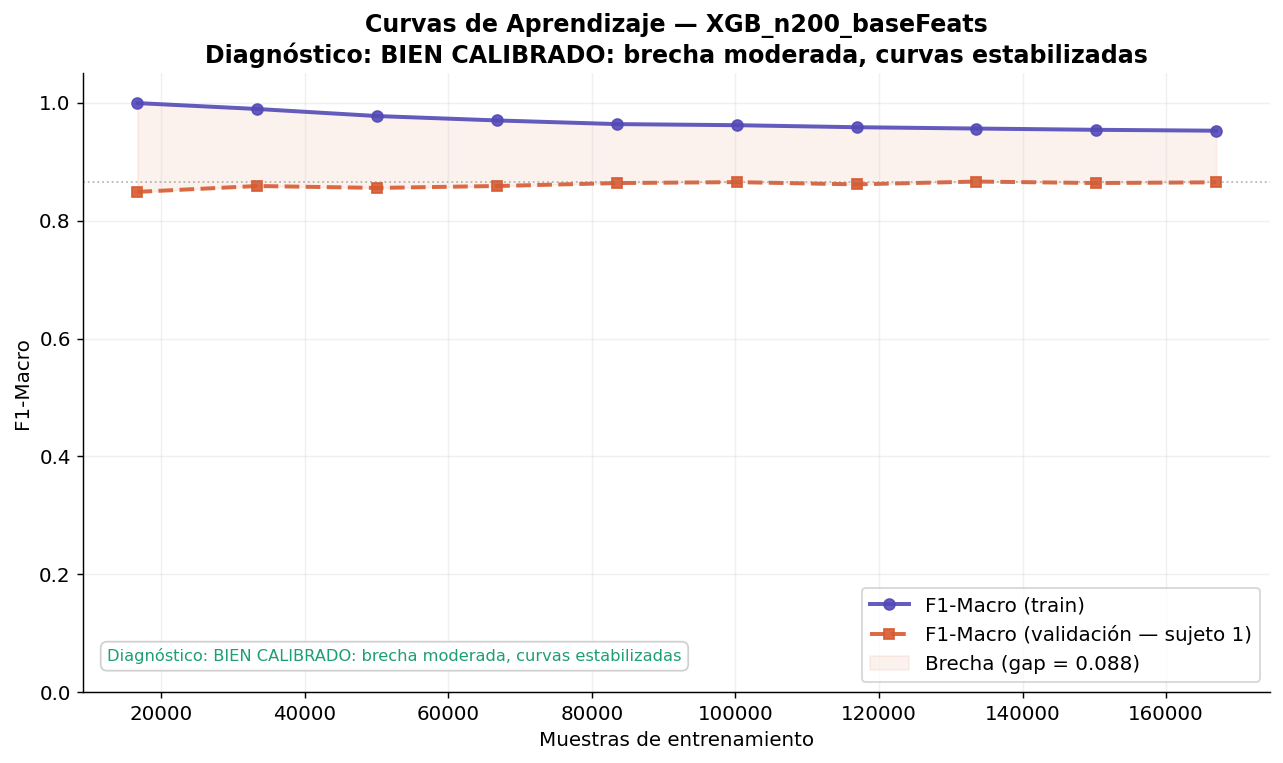

2026-05-28 20:42:37.400 | INFO     | posture_risk.experiments.diagnostics:plot_learning_curves:264 - Curva de aprendizaje guardada: reports\figures\08_learning_curves.png



Diagnóstico curvas de aprendizaje:
  BIEN CALIBRADO: brecha moderada, curvas estabilizadas
  F1-Macro final (train) : 0.9527
  F1-Macro final (val)   : 0.8651
  Brecha (gap)           : 0.0876
  ¿Curvas aún suben?     : False


In [12]:
import copy
pipe_lc = copy.deepcopy(pipe_xgb)

lc_results = plot_learning_curves(
    pipeline    = pipe_lc,
    X           = X_base,
    y           = y,
    groups      = subject_ids,
    output_path = FIGURES_DIR / "08_learning_curves.png",
    exp_name    = "XGB_n200_baseFeats",
    seed        = SEED,
)

print(f"\nDiagnóstico curvas de aprendizaje:")
print(f"  {lc_results['diagnosis']}")
print(f"  F1-Macro final (train) : {lc_results['train_f1_final']:.4f}")
print(f"  F1-Macro final (val)   : {lc_results['val_f1_final']:.4f}")
print(f"  Brecha (gap)           : {lc_results['final_gap']:.4f}")
print(f"  ¿Curvas aún suben?     : {lc_results['still_rising']}")

## 10. Diagnóstico: Curvas de calibración

- ¿Las probabilidades del modelo son fiables?
- Un sistema de alertas ergonómicas necesita probabilidades calibradas
  para decidir cuándo alertar al operador (no solo el rank)
- Brier score: 0 = calibración perfecta, 1 = peor posible

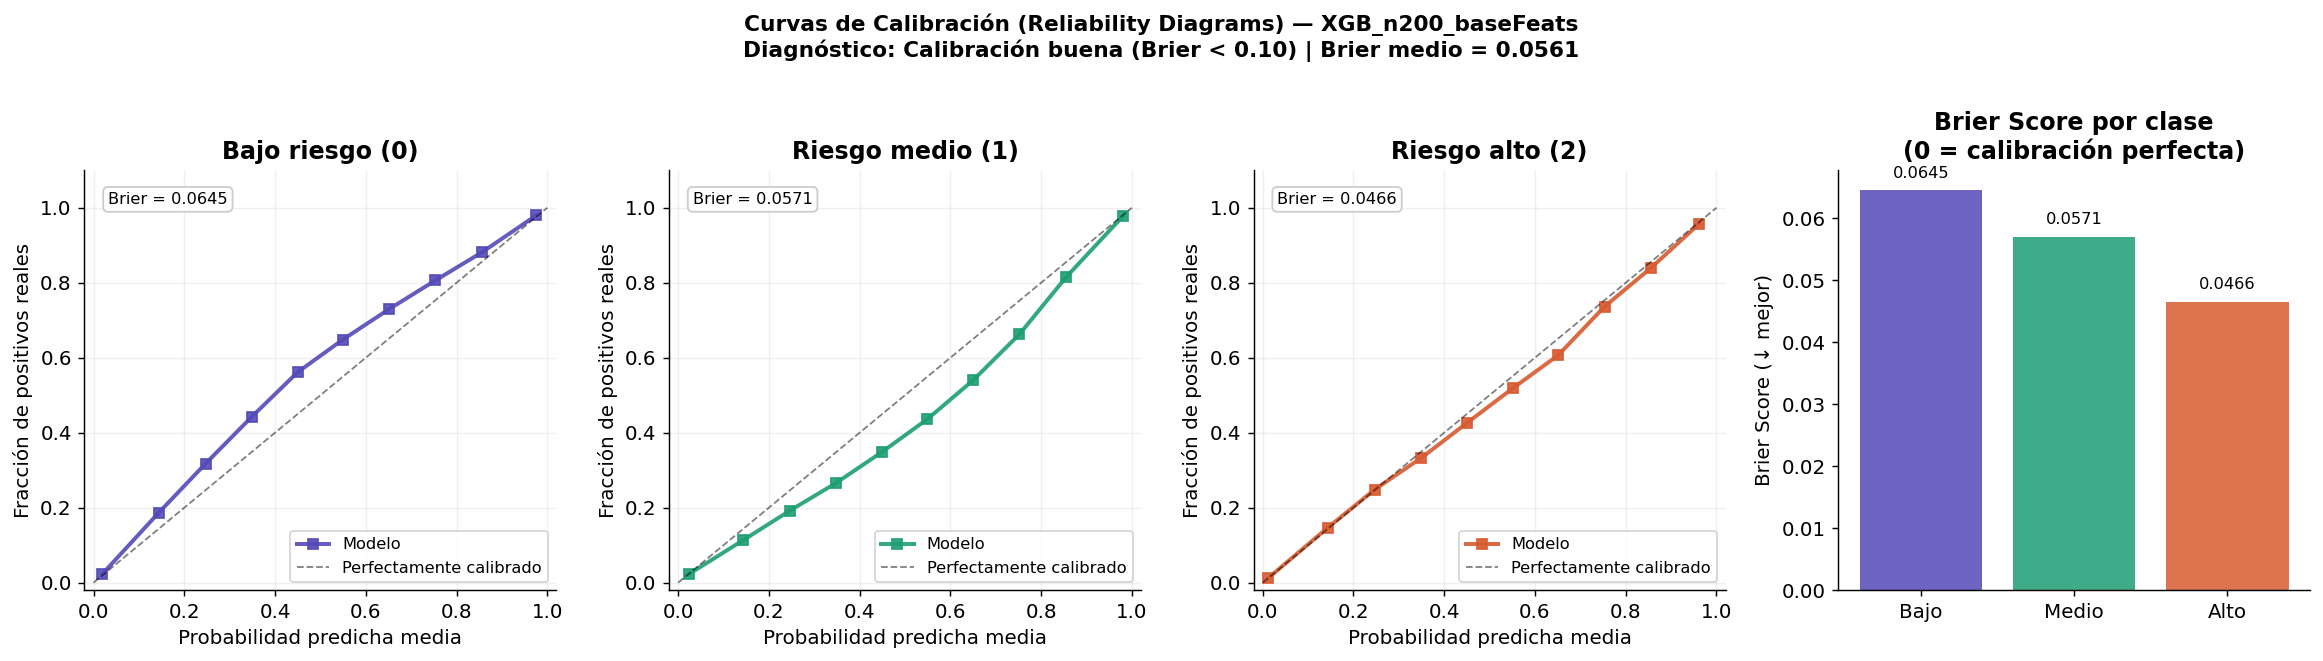

2026-05-28 20:42:40.651 | INFO     | posture_risk.experiments.diagnostics:plot_calibration_curves:366 - Curvas de calibración guardadas: reports\figures\09_calibration_curves.png



Diagnóstico calibración:
  Calibración buena (Brier < 0.10)
  Brier score por clase:
    class_0: 0.0645
    class_1: 0.0571
    class_2: 0.0466
  Brier score medio: 0.0561


In [13]:
cal_results = plot_calibration_curves(
    y_true      = results_xgb["y_true_all"],
    y_proba     = results_xgb["y_proba_all"],
    output_path = FIGURES_DIR / "09_calibration_curves.png",
    exp_name    = "XGB_n200_baseFeats",
)

print(f"\nDiagnóstico calibración:")
print(f"  {cal_results['calibration_diagnosis']}")
print(f"  Brier score por clase:")
for cls, bs in cal_results["brier_scores"].items():
    print(f"    {cls}: {bs:.4f}")
print(f"  Brier score medio: {cal_results['mean_brier']:.4f}")

## 11. Resumen ejecutivo del Sprint 2

In [14]:
print("\n" + "="*70)
print("RESUMEN EJECUTIVO — SPRINT 2 (SEMANA 6)")
print("="*70)

print("\n─── CHECKLIST DE VALIDACIÓN ────────────────────────────────────────")
items = [
    ("Ítem 1 — Split correcto (GroupKFold por sujeto)",    result_split["passed"]),
    ("Ítem 2 — Fit solo en train (sklearn.Pipeline)",      result_fit["passed"]),
    ("Ítem 3 — Seeds fijadas (seed=42, splits compartidos)",result_seeds["passed"]),
    ("Ítem 4 — Sin cambios de datos (hash MD5 verificado)",result_data["passed"]),
    ("Ítem 5 — Logs completos (config+métricas+timestamp)",result_logs["passed"]),
]
all_ok = all(passed for _, passed in items)
for label, passed in items:
    print(f"  {'✓' if passed else '✗'} {label}")
print(f"\n  RESULTADO GLOBAL: {'✓ TODO CORRECTO' if all_ok else '✗ HAY ÍTEMS FALLIDOS'}")

print("\n─── DIAGNÓSTICOS ────────────────────────────────────────────────────")
print(f"  Importancia : Top feature más importante → ver figura 07")
print(f"  Aprendizaje : {lc_results['diagnosis']}")
print(f"  Calibración : {cal_results['calibration_diagnosis']}")

print("\n─── MODELO ADOPTADO ────────────────────────────────────────────────")
print(f"  Nombre      : XGB_n200_baseFeats (EXP003)")
print(f"  F1-Macro    : {results_xgb['f1_macro_mean']:.4f} ± {results_xgb['f1_macro_std']:.4f}")
print(f"  PR-AUC      : {results_xgb['pr_auc_mean']:.4f} ± {results_xgb['pr_auc_std']:.4f}")
print(f"  Hash datos  : {base_hash[:20]}...")
print(f"  Git commit  : {get_git_commit()}")

print("\n─── FIGURAS GENERADAS ──────────────────────────────────────────────")
for fig_name in [
    "07_feature_importance_stability.png",
    "08_learning_curves.png",
    "09_calibration_curves.png",
]:
    path = FIGURES_DIR / fig_name
    status = "✓" if path.exists() else "✗"
    print(f"  {status} reports/figures/{fig_name}")
print("="*70)


RESUMEN EJECUTIVO — SPRINT 2 (SEMANA 6)

─── CHECKLIST DE VALIDACIÓN ────────────────────────────────────────
  ✓ Ítem 1 — Split correcto (GroupKFold por sujeto)
  ✓ Ítem 2 — Fit solo en train (sklearn.Pipeline)
  ✓ Ítem 3 — Seeds fijadas (seed=42, splits compartidos)
  ✓ Ítem 4 — Sin cambios de datos (hash MD5 verificado)
  ✓ Ítem 5 — Logs completos (config+métricas+timestamp)

  RESULTADO GLOBAL: ✓ TODO CORRECTO

─── DIAGNÓSTICOS ────────────────────────────────────────────────────
  Importancia : Top feature más importante → ver figura 07
  Aprendizaje : BIEN CALIBRADO: brecha moderada, curvas estabilizadas
  Calibración : Calibración buena (Brier < 0.10)

─── MODELO ADOPTADO ────────────────────────────────────────────────
  Nombre      : XGB_n200_baseFeats (EXP003)
  F1-Macro    : 0.8108 ± 0.2038
  PR-AUC      : 0.8863 ± 0.1957
  Hash datos  : a0ddfd044c46d683a6c8...
  Git commit  : fd3a839

─── FIGURAS GENERADAS ──────────────────────────────────────────────
  ✓ reports/figures/